In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/ai4i2020.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

Shape: (10000, 14)


In [2]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

failure_comparison = (
    df.groupby("Machine failure")[numeric_features]
      .agg(["mean", "median", "std"])
      .T
)

failure_comparison

Machine failure                           0            1
Air temperature [K]     mean     299.973999   300.886431
                        median   300.000000   301.600000
                        std        1.990748     2.071473
Process temperature [K] mean     309.995570   310.290265
                        median   310.000000   310.400000
                        std        1.486846     1.363686
Rotational speed [rpm]  mean    1540.260014  1496.486726
                        median  1507.000000  1365.000000
                        std      167.394734   384.943547
Torque [Nm]             mean      39.629655    50.168142
                        median    39.900000    53.700000
                        std        9.472080    16.374498
Tool wear [min]         mean     106.693717   143.781711
                        median   107.000000   165.000000
                        std       62.945790    72.759876

In [3]:
failure_counts = df["Machine failure"].value_counts()

print(failure_counts)

print("\nPercentage:")
print((failure_counts / len(df) * 100).round(2))

Machine failure
0    9661
1     339
Name: count, dtype: int64

Percentage:
Machine failure
0    96.61
1     3.39
Name: count, dtype: float64


In [4]:
failure_by_type = (
    df.groupby("Type")["Machine failure"]
      .agg(["count", "sum", "mean"])
      .rename(columns={
          "count": "total",
          "sum": "failures",
          "mean": "failure_rate"
      })
)

failure_by_type["failure_rate"] = failure_by_type["failure_rate"] * 100

failure_by_type

,total,failures,failure_rate
Type,,,
H,1003,21,2.093719
L,6000,235,3.916667
M,2997,83,2.769436


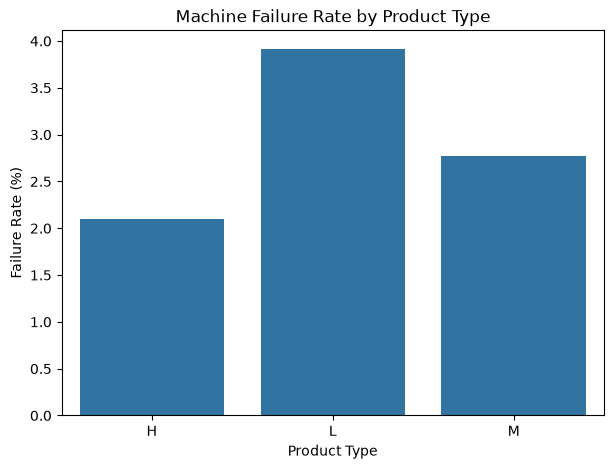

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))

sns.barplot(
    data=failure_by_type.reset_index(),
    x="Type",
    y="failure_rate"
)

plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")
plt.show()

In [6]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

comparison = (
    df.groupby("Machine failure")[numeric_features]
      .agg(["mean", "median", "std"])
      .T
)

comparison

Machine failure                           0            1
Air temperature [K]     mean     299.973999   300.886431
                        median   300.000000   301.600000
                        std        1.990748     2.071473
Process temperature [K] mean     309.995570   310.290265
                        median   310.000000   310.400000
                        std        1.486846     1.363686
Rotational speed [rpm]  mean    1540.260014  1496.486726
                        median  1507.000000  1365.000000
                        std      167.394734   384.943547
Torque [Nm]             mean      39.629655    50.168142
                        median    39.900000    53.700000
                        std        9.472080    16.374498
Tool wear [min]         mean     106.693717   143.781711
                        median   107.000000   165.000000
                        std       62.945790    72.759876

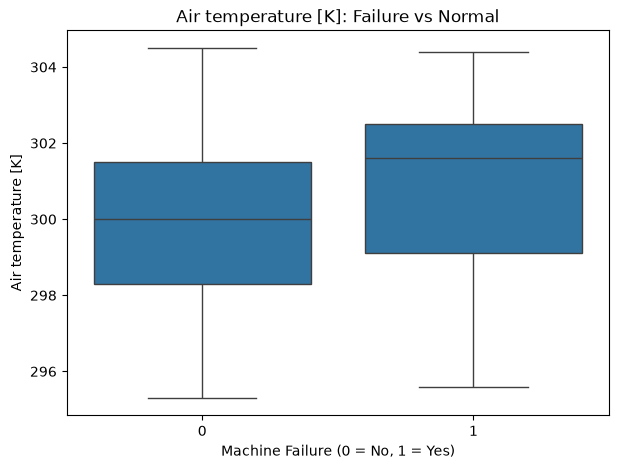

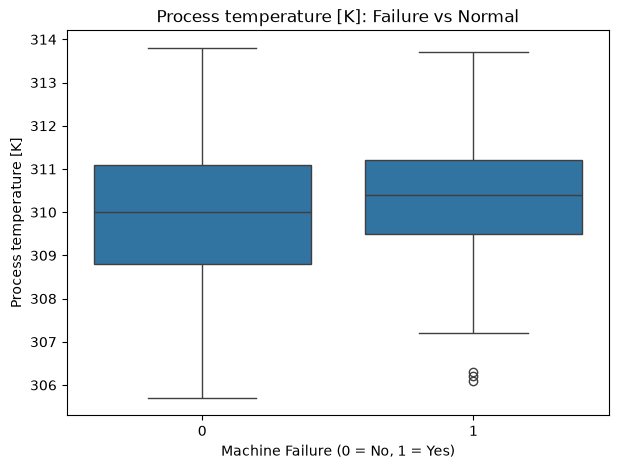

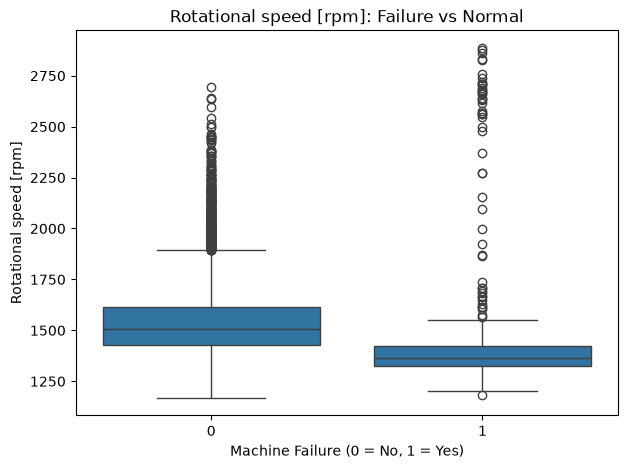

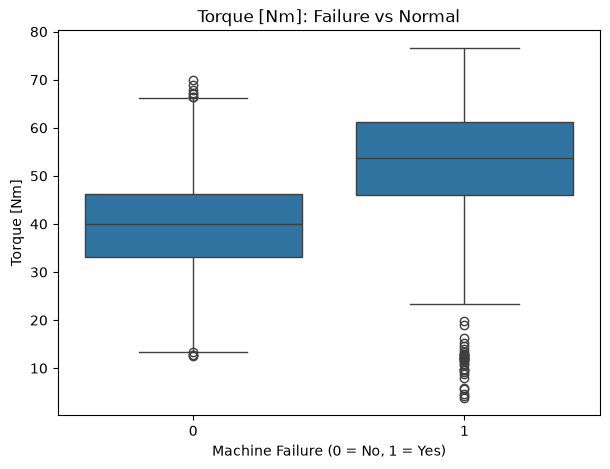

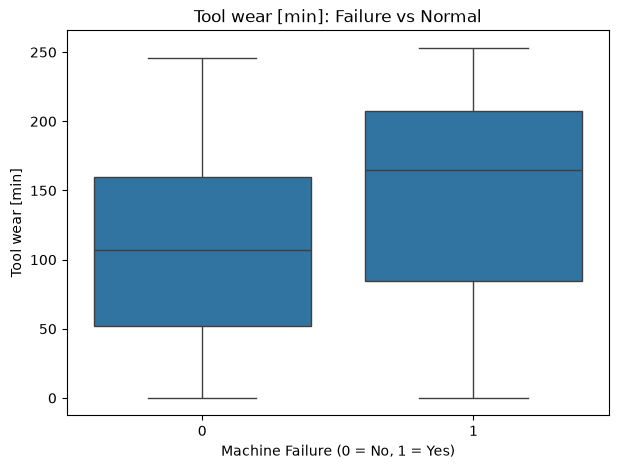

In [7]:
for feature in numeric_features:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=feature
    )

    plt.title(f"{feature}: Failure vs Normal")
    plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
    plt.ylabel(feature)

    plt.show()

In [8]:
df["temp_diff"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

df["power_w"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
    * 2 * np.pi / 60
)

df["wear_torque"] = (
    df["Tool wear [min]"]
    * df["Torque [Nm]"]
)

df[[
    "temp_diff",
    "power_w",
    "wear_torque"
]].describe()

,temp_diff,power_w,wear_torque
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,4314.664550
std,1.001094,1067.418295,2826.567692
min,7.600000,1148.440610,0.000000
25%,9.300000,5561.184484,1963.650000
50%,9.800000,6271.027344,4012.950000
75%,11.000000,7003.002724,6279.000000
max,12.100000,10469.923005,16497.000000


In [9]:
engineered_features = [
    "temp_diff",
    "power_w",
    "wear_torque"
]

df.groupby("Machine failure")[engineered_features].agg(
    ["mean", "median", "std"]
).T

Machine failure               0            1
temp_diff   mean      10.021571     9.403835
            median     9.800000     9.300000
            std        0.988422     1.164445
power_w     mean    6244.547534  7282.819485
            median  6243.046225  7611.429737
            std     1011.394393  1851.137977
wear_torque mean    4213.842708  7187.938348
            median  3952.800000  7681.800000
            std     2709.744211  4234.039961

In [10]:
df["wear_bin"] = pd.cut(
    df["Tool wear [min]"],
    bins=[0, 50, 100, 150, 200, 250, 300],
    right=False
)

wear_failure = (
    df.groupby("wear_bin", observed=True)["Machine failure"]
      .agg(["count", "sum", "mean"])
)

wear_failure["failure_rate"] = wear_failure["mean"] * 100

wear_failure

,count,sum,mean,failure_rate
wear_bin,,,,
"[0, 50)",2349,52,0.022137,2.213708
"[50, 100)",2271,51,0.022457,2.245707
"[100, 150)",2290,52,0.022707,2.270742
"[150, 200)",2289,61,0.026649,2.664919
"[200, 250)",799,121,0.151439,15.143930
"[250, 300)",2,2,1.000000,100.000000


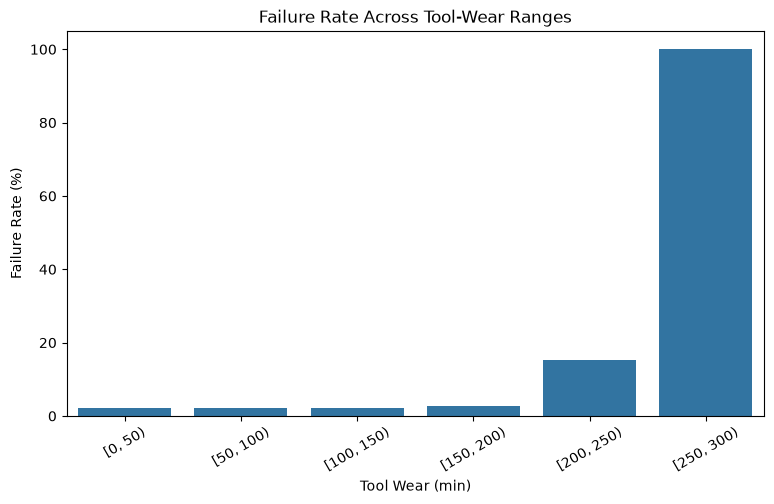

In [11]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=wear_failure.reset_index(),
    x="wear_bin",
    y="failure_rate"
)

plt.title("Failure Rate Across Tool-Wear Ranges")
plt.xlabel("Tool Wear (min)")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [12]:
df["torque_bin"] = pd.cut(
    df["Torque [Nm]"],
    bins=6
)

torque_failure = (
    df.groupby("torque_bin", observed=True)["Machine failure"]
      .agg(["count", "sum", "mean"])
)

torque_failure["failure_rate"] = torque_failure["mean"] * 100

torque_failure

,count,sum,mean,failure_rate
torque_bin,,,,
"(3.727, 15.933]",81,31,0.382716,38.271605
"(15.933, 28.067]",1076,8,0.007435,0.743494
"(28.067, 40.2]",3870,23,0.005943,0.594315
"(40.2, 52.333]",3918,90,0.022971,2.297090
"(52.333, 64.467]",985,133,0.135025,13.502538
"(64.467, 76.6]",70,54,0.771429,77.142857


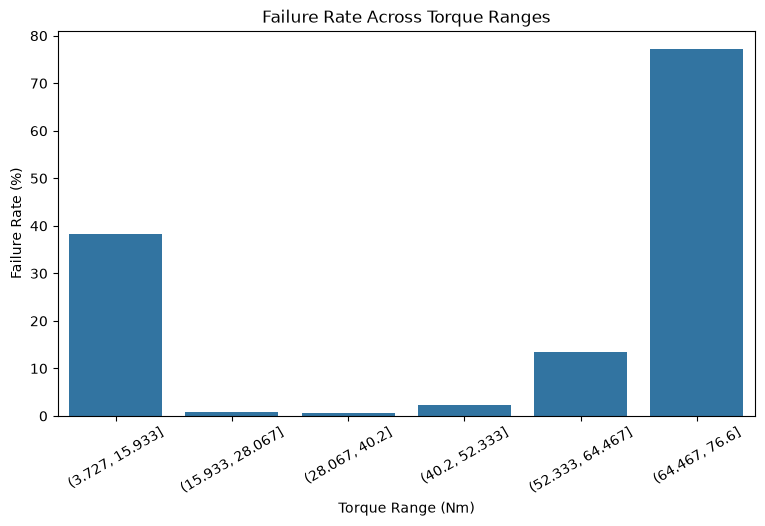

In [13]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=torque_failure.reset_index(),
    x="torque_bin",
    y="failure_rate"
)

plt.title("Failure Rate Across Torque Ranges")
plt.xlabel("Torque Range (Nm)")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [14]:
df["rpm_bin"] = pd.cut(
    df["Rotational speed [rpm]"],
    bins=6
)

rpm_failure = (
    df.groupby("rpm_bin", observed=True)["Machine failure"]
      .agg(["count", "sum", "mean"])
)

rpm_failure["failure_rate"] = rpm_failure["mean"] * 100

rpm_failure

,count,sum,mean,failure_rate
rpm_bin,,,,
"(1166.282, 1454.333]",3528,269,0.076247,7.624717
"(1454.333, 1740.667]",5437,33,0.006070,0.606952
"(1740.667, 2027.0]",838,4,0.004773,0.477327
"(2027.0, 2313.333]",137,4,0.029197,2.919708
"(2313.333, 2599.667]",36,8,0.222222,22.222222
"(2599.667, 2886.0]",24,21,0.875000,87.500000


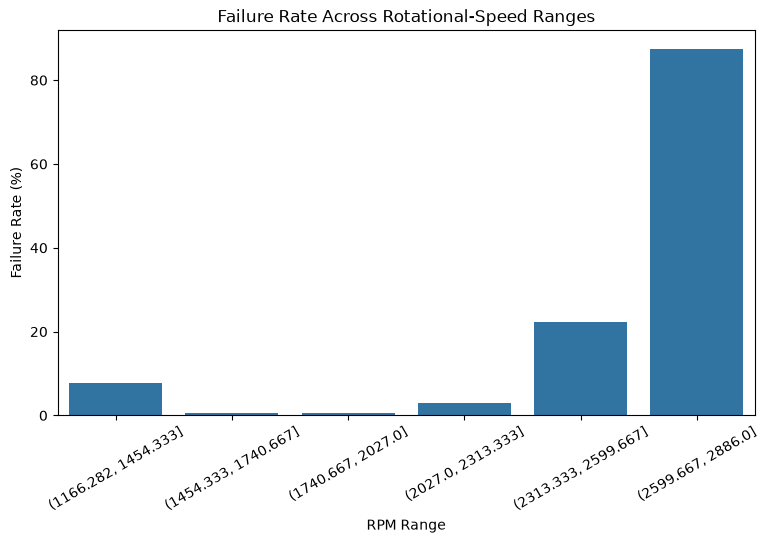

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=rpm_failure.reset_index(),
    x="rpm_bin",
    y="failure_rate"
)

plt.title("Failure Rate Across Rotational-Speed Ranges")
plt.xlabel("RPM Range")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)
plt.show()

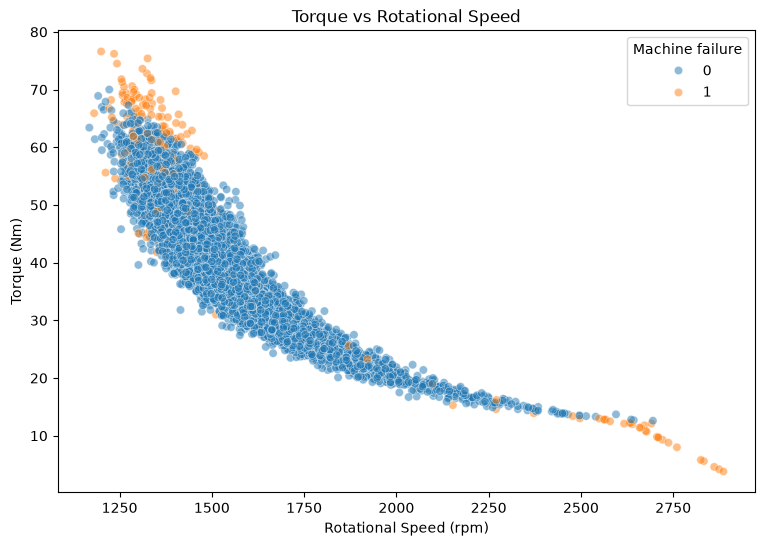

In [16]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Machine failure",
    alpha=0.5
)

plt.title("Torque vs Rotational Speed")
plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Torque (Nm)")
plt.show()

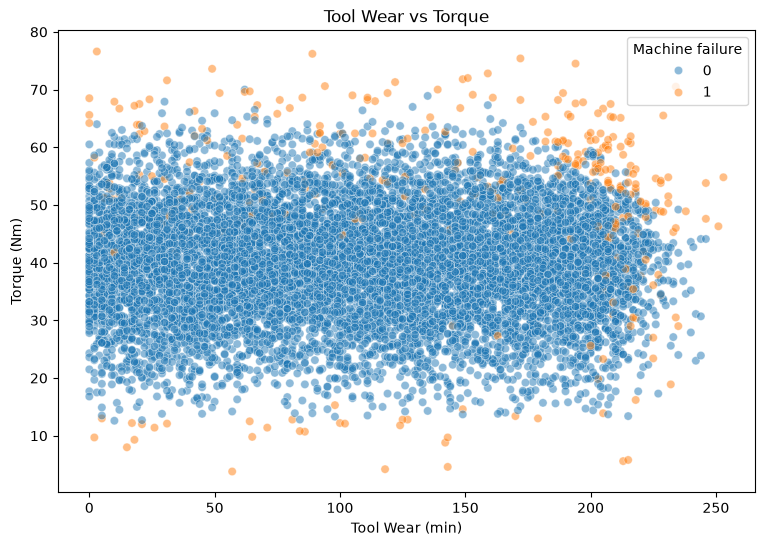

In [17]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Tool wear [min]",
    y="Torque [Nm]",
    hue="Machine failure",
    alpha=0.5
)

plt.title("Tool Wear vs Torque")
plt.xlabel("Tool Wear (min)")
plt.ylabel("Torque (Nm)")
plt.show()

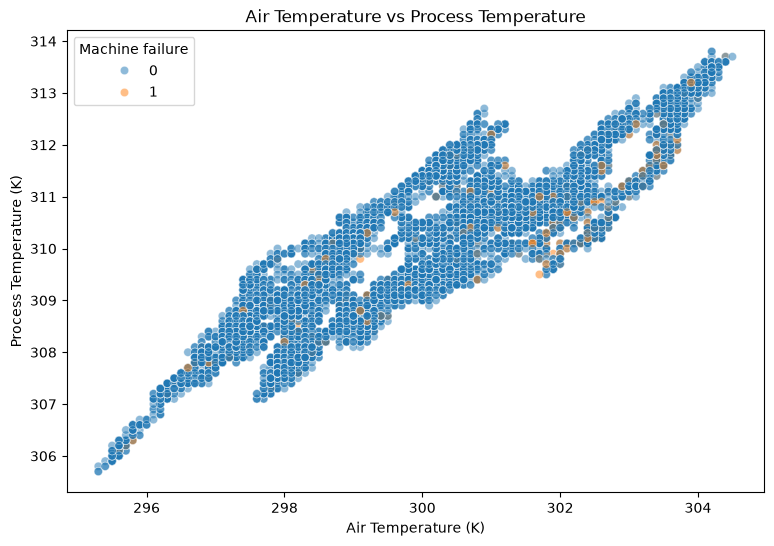

In [18]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue="Machine failure",
    alpha=0.5
)

plt.title("Air Temperature vs Process Temperature")
plt.xlabel("Air Temperature (K)")
plt.ylabel("Process Temperature (K)")
plt.show()

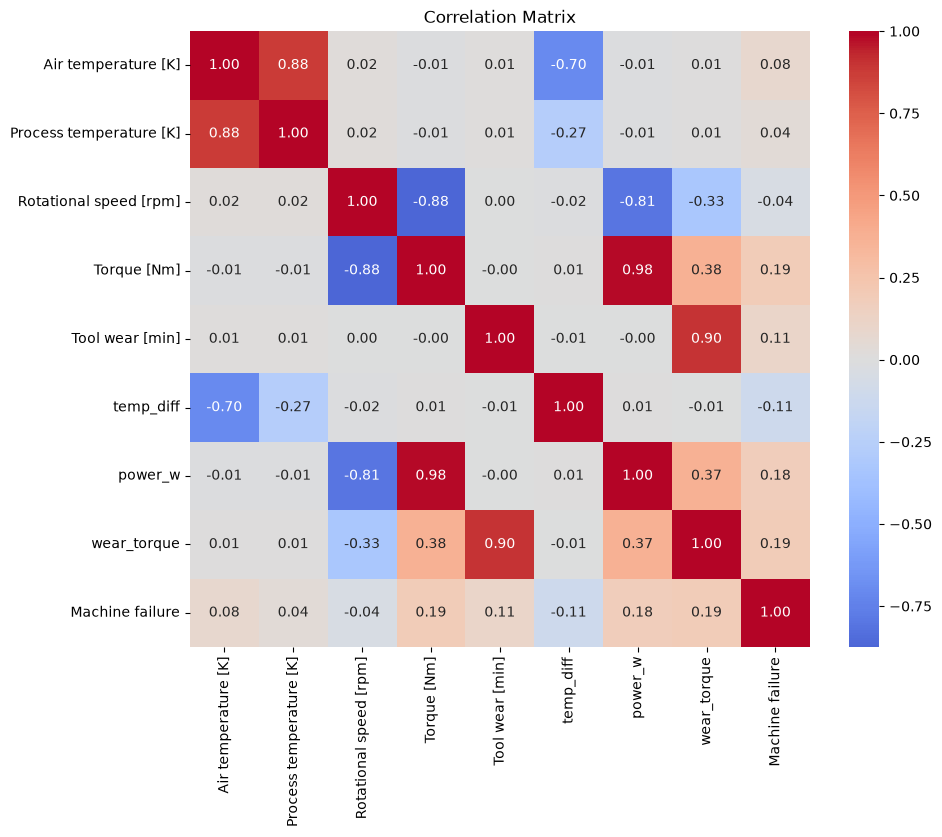

In [19]:
corr_features = numeric_features + [
    "temp_diff",
    "power_w",
    "wear_torque",
    "Machine failure"
]

corr = df[corr_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()